In [1]:
# path loacted at "E:\geodata\gebco_2024_sub_ice_topo\GEBCO_2024_sub_ice_topo.nc"

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [3]:
# Load the NetCDF file
ds = xr.open_dataset("E:/geodata/gebco_2024_sub_ice_topo/GEBCO_2024_sub_ice_topo.nc")

In [4]:
# Select region bounds
lon_min, lon_max = -94, -88
lat_min, lat_max = 27.5, 30.5

# Subset the data
subset = ds.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))

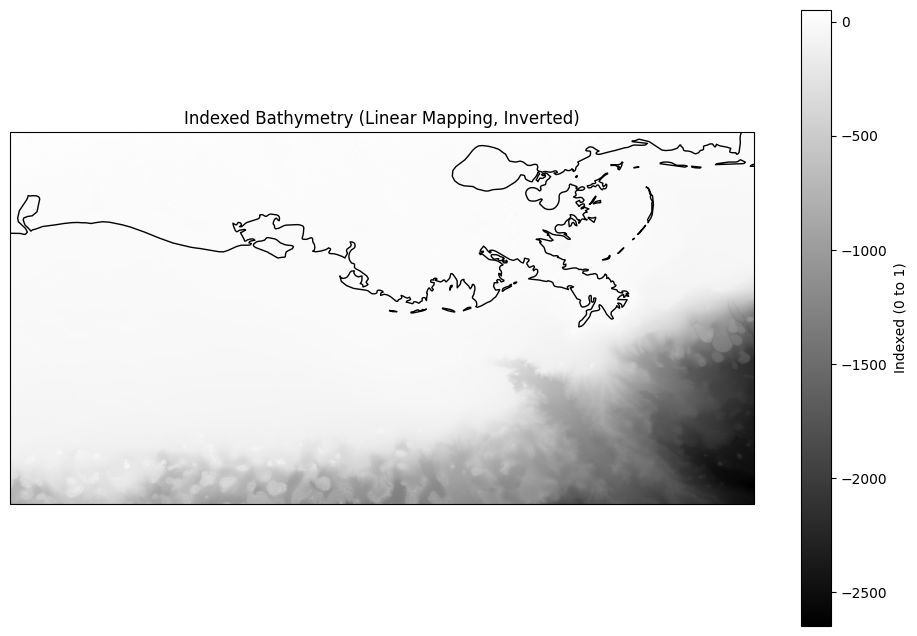

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Extract bathymetry data from the subset
bathymetry = subset['elevation']  # GEBCO uses 'elevation' as the variable name
bathy = bathymetry.values if hasattr(bathymetry, 'values') else bathymetry

# Plotting
plt.figure(figsize=(12,8))
ax = plt.axes(projection=ccrs.PlateCarree())
im = ax.pcolormesh(subset['lon'], subset['lat'], bathy, cmap='gray', shading='auto')
ax.coastlines()
ax.set_extent([lon_min, lon_max, lat_min, lat_max])
plt.colorbar(im, label='Bathymetry (meters)')
plt.title('Bathymetry Data')
plt.show()